# 论文 Figure2

In [ ]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
import psutil
import gc
import chess
import chess.engine
import chess.svg
from IPython.display import display, HTML
import subprocess
import time
from pathlib import Path
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
from scipy.interpolate import UnivariateSpline
from sklearn.metrics import mean_squared_error
from scipy import stats


df_moves = pd.read_parquet(r'..\df_moves6.parquet')

# version 1: p_model related to A, τ, x0

## picture 1:    
### x-axis:Δ_top5   
### y-axis:P_model & P_emp     
### with error bar

拟合参数的代码

Processing ELO: >=3000 ...


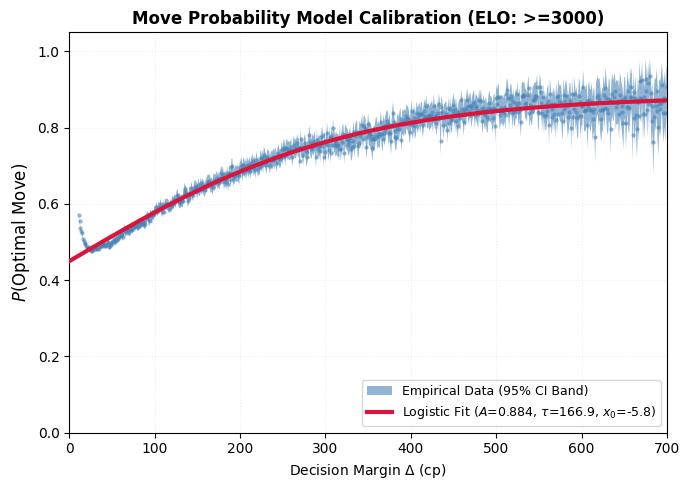


--- ELO >=3000 关键节点的预测波动 (95% CI) ---
 Delta  |  Predicted P  |  95% CI Fluctuation (±)
--------|---------------|-------------------------
  20    |     0.476     |      ± 0.0049
  50    |     0.515     |      ± 0.0039
  100   |     0.578     |      ± 0.0027
  200   |     0.685     |      ± 0.0026
  400   |     0.813     |      ± 0.0021
  600   |     0.861     |      ± 0.0025
--------------------------------------------------
Processing ELO: 2800-3000 ...


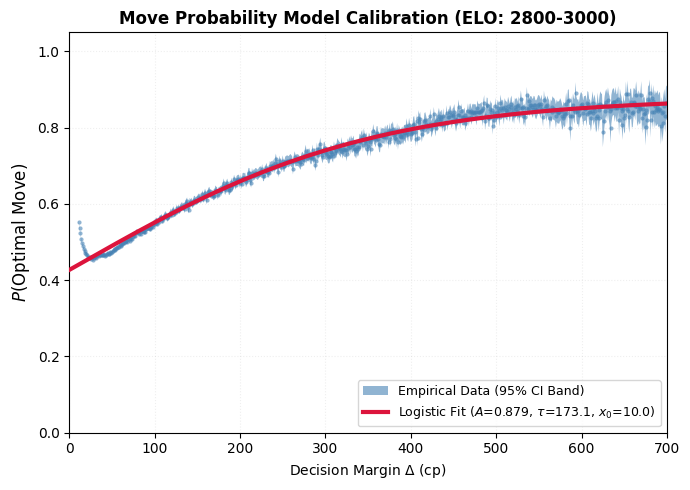


--- ELO 2800-3000 关键节点的预测波动 (95% CI) ---
 Delta  |  Predicted P  |  95% CI Fluctuation (±)
--------|---------------|-------------------------
  20    |     0.452     |      ± 0.0035
  50    |     0.490     |      ± 0.0030
  100   |     0.551     |      ± 0.0021
  200   |     0.659     |      ± 0.0018
  400   |     0.796     |      ± 0.0016
  600   |     0.851     |      ± 0.0020
--------------------------------------------------
Processing ELO: 2600-2800 ...


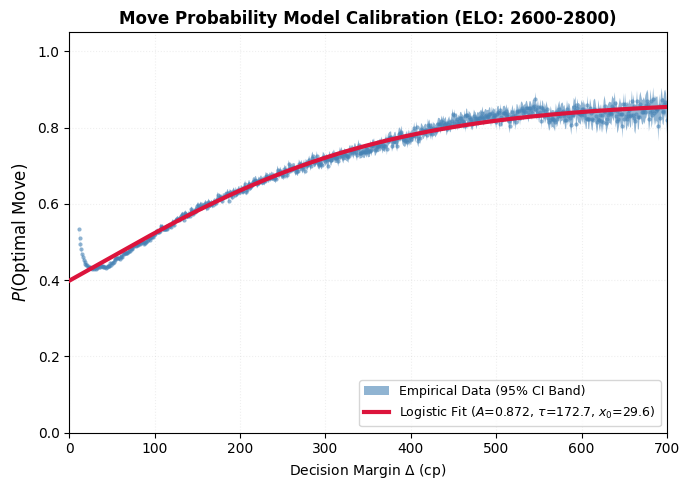


--- ELO 2600-2800 关键节点的预测波动 (95% CI) ---
 Delta  |  Predicted P  |  95% CI Fluctuation (±)
--------|---------------|-------------------------
  20    |     0.424     |      ± 0.0031
  50    |     0.462     |      ± 0.0025
  100   |     0.524     |      ± 0.0018
  200   |     0.635     |      ± 0.0016
  400   |     0.781     |      ± 0.0014
  600   |     0.841     |      ± 0.0018
--------------------------------------------------
Processing ELO: 2400-2600 ...


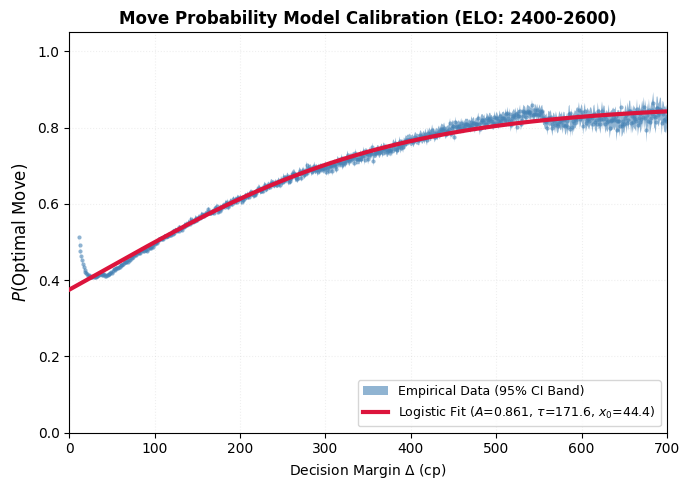


--- ELO 2400-2600 关键节点的预测波动 (95% CI) ---
 Delta  |  Predicted P  |  95% CI Fluctuation (±)
--------|---------------|-------------------------
  20    |     0.400     |      ± 0.0033
  50    |     0.438     |      ± 0.0028
  100   |     0.500     |      ± 0.0019
  200   |     0.613     |      ± 0.0016
  400   |     0.765     |      ± 0.0014
  600   |     0.829     |      ± 0.0018
--------------------------------------------------
Processing ELO: 2200-2400 ...


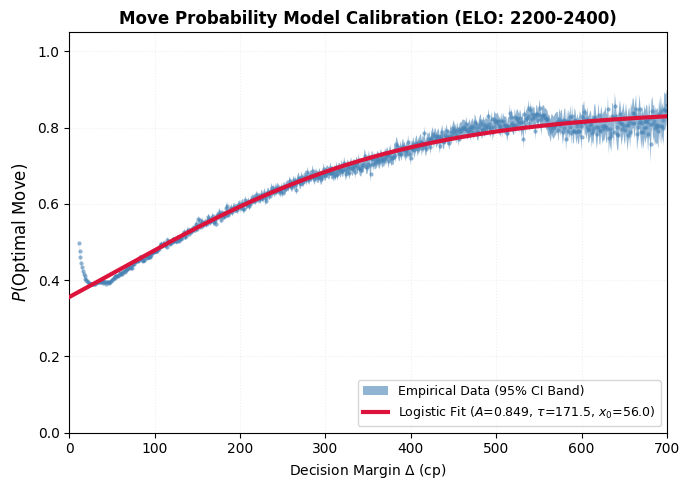


--- ELO 2200-2400 关键节点的预测波动 (95% CI) ---
 Delta  |  Predicted P  |  95% CI Fluctuation (±)
--------|---------------|-------------------------
  20    |     0.380     |      ± 0.0038
  50    |     0.417     |      ± 0.0032
  100   |     0.479     |      ± 0.0024
  200   |     0.593     |      ± 0.0020
  400   |     0.748     |      ± 0.0019
  600   |     0.815     |      ± 0.0023
--------------------------------------------------
Processing ELO: 2000-2200 ...


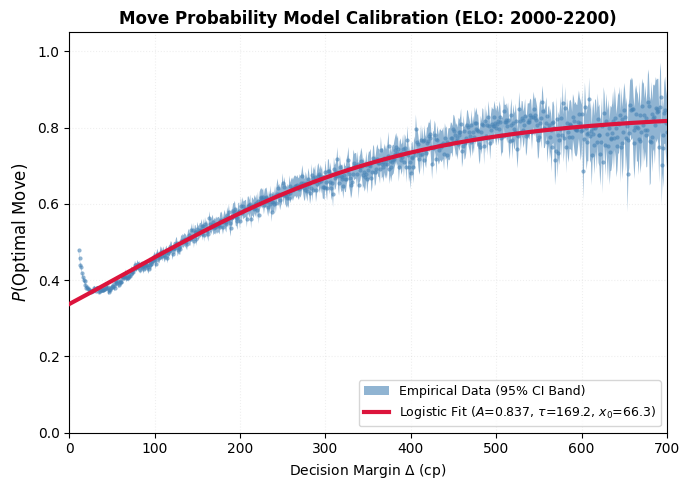


--- ELO 2000-2200 关键节点的预测波动 (95% CI) ---
 Delta  |  Predicted P  |  95% CI Fluctuation (±)
--------|---------------|-------------------------
  20    |     0.362     |      ± 0.0054
  50    |     0.398     |      ± 0.0047
  100   |     0.460     |      ± 0.0036
  200   |     0.576     |      ± 0.0030
  400   |     0.735     |      ± 0.0026
  600   |     0.803     |      ± 0.0033
--------------------------------------------------
Processing ELO: <2000 ...


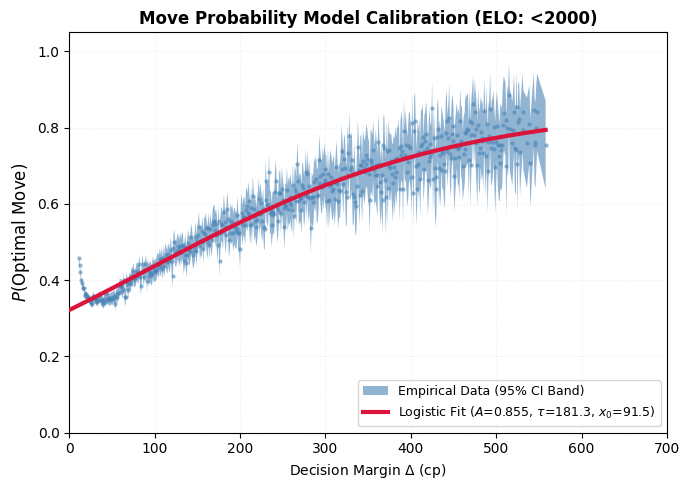


--- ELO <2000 关键节点的预测波动 (95% CI) ---
 Delta  |  Predicted P  |  95% CI Fluctuation (±)
--------|---------------|-------------------------
  20    |     0.344     |      ± 0.0077
  50    |     0.379     |      ± 0.0065
  100   |     0.437     |      ± 0.0049
  200   |     0.552     |      ± 0.0044
  400   |     0.723     |      ± 0.0042
  600   |     0.806     |      ± 0.0103
--------------------------------------------------

Summary of Fitting Parameters:
ELO_Group     A   tau   x0  A_err  tau_err  x0_err  Max_CI_Width  d_max  min_cnt
   >=3000 0.884 166.9 -5.8 0.0024     2.94    1.91        0.0111    700       50
2800-3000 0.879 173.1 10.0 0.0020     2.24    1.34        0.0079    700       50
2600-2800 0.872 172.7 29.6 0.0018     1.91    1.10        0.0070    700       80
2400-2600 0.861 171.6 44.4 0.0019     1.86    1.07        0.0073    700       80
2200-2400 0.849 171.5 56.0 0.0023     2.21    1.28        0.0084    700       80
2000-2200 0.837 169.2 66.3 0.0034     3.17    1.88  

In [2]:
# 新的拟合函数
def empirical_curve(df, group_name, delta_min = 10, delta_max = 800, min_count = 100, bin_size=1):
    group_df = df[(df['ELO_Group'] == group_name) & (df['Is_Forced'] == 0)]
    group_df = group_df[(group_df['Δ'] > delta_min) & (group_df['Δ'] <= delta_max)]
    if group_df.empty: return None
    group_df['Δ_bin'] = (group_df['Δ'] // bin_size) * bin_size

    # 第一步：计算每个 Δ 的总步数，并过滤掉少于 min_count 的
    counts = group_df.groupby('Δ_bin')['Is_Optimal'].count()
    valid_deltas = counts[counts >= min_count].index
    group_df = group_df[group_df['Δ_bin'].isin(valid_deltas)]

    if group_df.empty: return None
    
    prob_df = group_df.groupby('Δ_bin')['Is_Optimal'].agg(
        P_Optimal='mean',
        Count='count'
    ).reset_index()
    
    # 重命名列并排序
    prob_df = prob_df.rename(columns={'Δ_bin': 'Δ'})
    prob_df = prob_df.sort_values('Δ').reset_index(drop=True)
    return prob_df

def theoretical_logistic_shifted(x, A, tau, x0):
    x_safe = np.clip(-(x - x0) / tau, -500, 500)
    return A / (1 + np.exp(x_safe))

def fit_mse_shifted(prob_df):
    x_data = prob_df['Δ'].values
    y_data = prob_df['P_Optimal'].values
    
    p0 = [0.85, 200, 50] 
    bounds = ([0.0, 1.0, -500.0], [1.0, 1000.0, 500.0])
    
    try:
        popt, pcov = curve_fit(theoretical_logistic_shifted, x_data, y_data, p0=p0, bounds=bounds)
        # popt [A, TAU, X0]
        # pcov 协方差矩阵
        return popt, pcov
    except Exception as e:
        print(f"Fit failed: {e}")
        return None, None

# 配置遍历参数，人为可调节
group_order = ['>=3000', '2800-3000', '2600-2800', '2400-2600', '2200-2400', '2000-2200', '<2000']
group_configs = {
    '>=3000':   {'delta_max': 700,  'min_count': 50},  
    '2800-3000':{'delta_max': 700,  'min_count': 50},
    '2600-2800':{'delta_max': 700,  'min_count': 80},
    '2400-2600':{'delta_max': 700,  'min_count': 80}, 
    '2200-2400':{'delta_max': 700,  'min_count': 80},
    '2000-2200':{'delta_max': 700,  'min_count': 50},
    '<2000':    {'delta_max': 700,  'min_count': 50}  
}

summary_results = []

# 画图
for g in group_order:
    print(f'Processing ELO: {g} ...')
    
    cfg = group_configs.get(g, {'delta_max': 800, 'min_count': 50})
    d_max = cfg['delta_max']
    m_cnt = cfg['min_count']
    
    prob_df = empirical_curve(df_moves[df_moves['Is_Forced'] == 0], group_name=g, 
        delta_min=10, delta_max=d_max, min_count=m_cnt)
    # 数据不足的组跳过
    if prob_df is None or prob_df.empty:
        print(f"Insufficient data for group {g}, skipping.")
        continue

    popt, pcov = fit_mse_shifted(prob_df)
    
    if popt is not None:
        A, tau, x0 = popt
        perr = np.sqrt(np.diag(pcov))  #协方差矩阵对角线开根号为标准差
        
        x_data = prob_df['Δ'].values
        y_data = prob_df['P_Optimal'].values
        n_data = prob_df['Count'].values
        # 二项分布的 95% CI 半径
        y_err = 1.96 * np.sqrt(y_data * (1 - y_data) / n_data)
        
        x_smooth = np.linspace(0, x_data.max(), 200) 
        y_smooth = theoretical_logistic_shifted(x_smooth, A, tau, x0)

        # 阴影生成逻辑 (保持不变)
        sample_params = np.random.multivariate_normal(popt, pcov, 1000)
        valid_params = []
        for params in sample_params:
            A_s, tau_s, x0_s = params
            if 0 < A_s < 1 and tau_s > 0:
                valid_params.append(params)

        valid_params = np.array(valid_params)
        y_samples = np.array([theoretical_logistic_shifted(x_smooth, *params) for params in valid_params])

        y_lower = np.percentile(y_samples, 2.5, axis=0)
        y_upper = np.percentile(y_samples, 97.5, axis=0)

        # 阴影生成逻辑
        sample_params = np.random.multivariate_normal(popt, pcov, 1000)
        valid_params = []
        # 过滤无效参数
        for params in sample_params:
            A_s, tau_s, x0_s = params
            if 0 < A_s < 1 and tau_s > 0:
                valid_params.append(params)

        valid_params = np.array(valid_params)
        y_samples = np.array([theoretical_logistic_shifted(x_smooth, *params) for params in valid_params])

        y_lower = np.percentile(y_samples, 2.5, axis=0)
        y_upper = np.percentile(y_samples, 97.5, axis=0)
        
        max_band_width = np.max(y_upper - y_lower)
        
        # 记录汇总数据
        summary_results.append({
            'ELO_Group': g,
            'A': round(A, 3),
            'tau': round(tau, 1),
            'x0': round(x0, 1),
            'A_err': round(perr[0], 4),
            'tau_err': round(perr[1], 2),
            'x0_err': round(perr[2], 2),
            'Max_CI_Width': round(max_band_width, 4),
            'd_max': d_max,
            'min_cnt': m_cnt
        })
        
        # 绘图部分：实装可视化升级策略
        plt.figure(figsize=(7, 5))
        
        # 策略 1: 弱化数据。将数据放在最底层 (zorder=1)，并极度透明 (alpha=0.15~0.25)
        # 策略 2: 修改图例名称为不含混的术语：'Observed Data & 95% CI'
        # 我们还把误差棒和点分开画，以实现极致的视觉弱化
        
        # 先画误差棒，极其半透明，像一团背景云
        plt.fill_between(x_data, y_data - y_err, y_data + y_err, 
                         color='steelblue', alpha=0.6, edgecolor='none', 
                         label='Empirical Data (95% CI Band)', zorder=1)
        
        # 2. 画出经验数据的中心散点
        plt.plot(x_data, y_data, 'o', color='steelblue', alpha=0.6, markersize=3, 
                 markeredgecolor='none', zorder=2)
        
        # 策略 3: 强调模型。将模型放在最上层 (zorder=3)，红线放在最最上层 (zorder=4)
        # 画理论拟合曲线 (粗红线)，放在最顶层 (zorder=4)
        fit_label = f'Logistic Fit ($A$={A:.3f}, $\\tau$={tau:.1f}, $x_0$={x0:.1f})'
        plt.plot(x_smooth, y_smooth, '-', color='crimson', lw=3.0, label=fit_label, alpha=1.0, zorder=10)
        
        plt.title(f'Move Probability Model Calibration (ELO: {g})', fontsize=12, fontweight='bold')
        plt.xlabel(r'Decision Margin $\Delta$ (cp)', fontsize=10)
        plt.ylabel(r'$P(\text{Optimal Move})$', fontsize=12)
        plt.ylim(0, 1.05)
        plt.xlim(0, max(d_max, x_smooth.max()))
        
        # 调整图例位置和透明度，使其不遮挡曲线
        plt.legend(loc='lower right', fontsize=9, framealpha=0.8)
        
        plt.grid(alpha=0.2, linestyle=':')
        plt.tight_layout()
        plt.show()

        # 打印不同横坐标时候的不确定误差       
        target_deltas = np.array([20, 50, 100, 200, 400, 600])
        # 这几个点的理论预测中心值
        y_targets_center = theoretical_logistic_shifted(target_deltas, A, tau, x0)
        # 这几个点的 1000 个可能的 Y 值
        y_targets_samples = np.array([theoretical_logistic_shifted(target_deltas, *params) for params in valid_params])
        # 提取 95% 置信区间的上下界
        y_targets_lower = np.percentile(y_targets_samples, 2.5, axis=0)
        y_targets_upper = np.percentile(y_targets_samples, 97.5, axis=0)
        # 上下浮动的幅度 (即 ± 的那个数字)
        fluctuations = (y_targets_upper - y_targets_lower) / 2
        print(f"\n--- ELO {g} 关键节点的预测波动 (95% CI) ---")
        print(" Delta  |  Predicted P  |  95% CI Fluctuation (±)")
        print("--------|---------------|-------------------------")
        for i in range(len(target_deltas)):
            d = target_deltas[i]
            p_val = y_targets_center[i]
            fluc = fluctuations[i]
            print(f"  {d:<4}  |     {p_val:.3f}     |      ± {fluc:.4f}")
        print("-" * 50)

# 打印最终参数汇总表
print('\nSummary of Fitting Parameters:')
summary_df = pd.DataFrame(summary_results)
print(summary_df.to_string(index=False))

组图+error bar版本

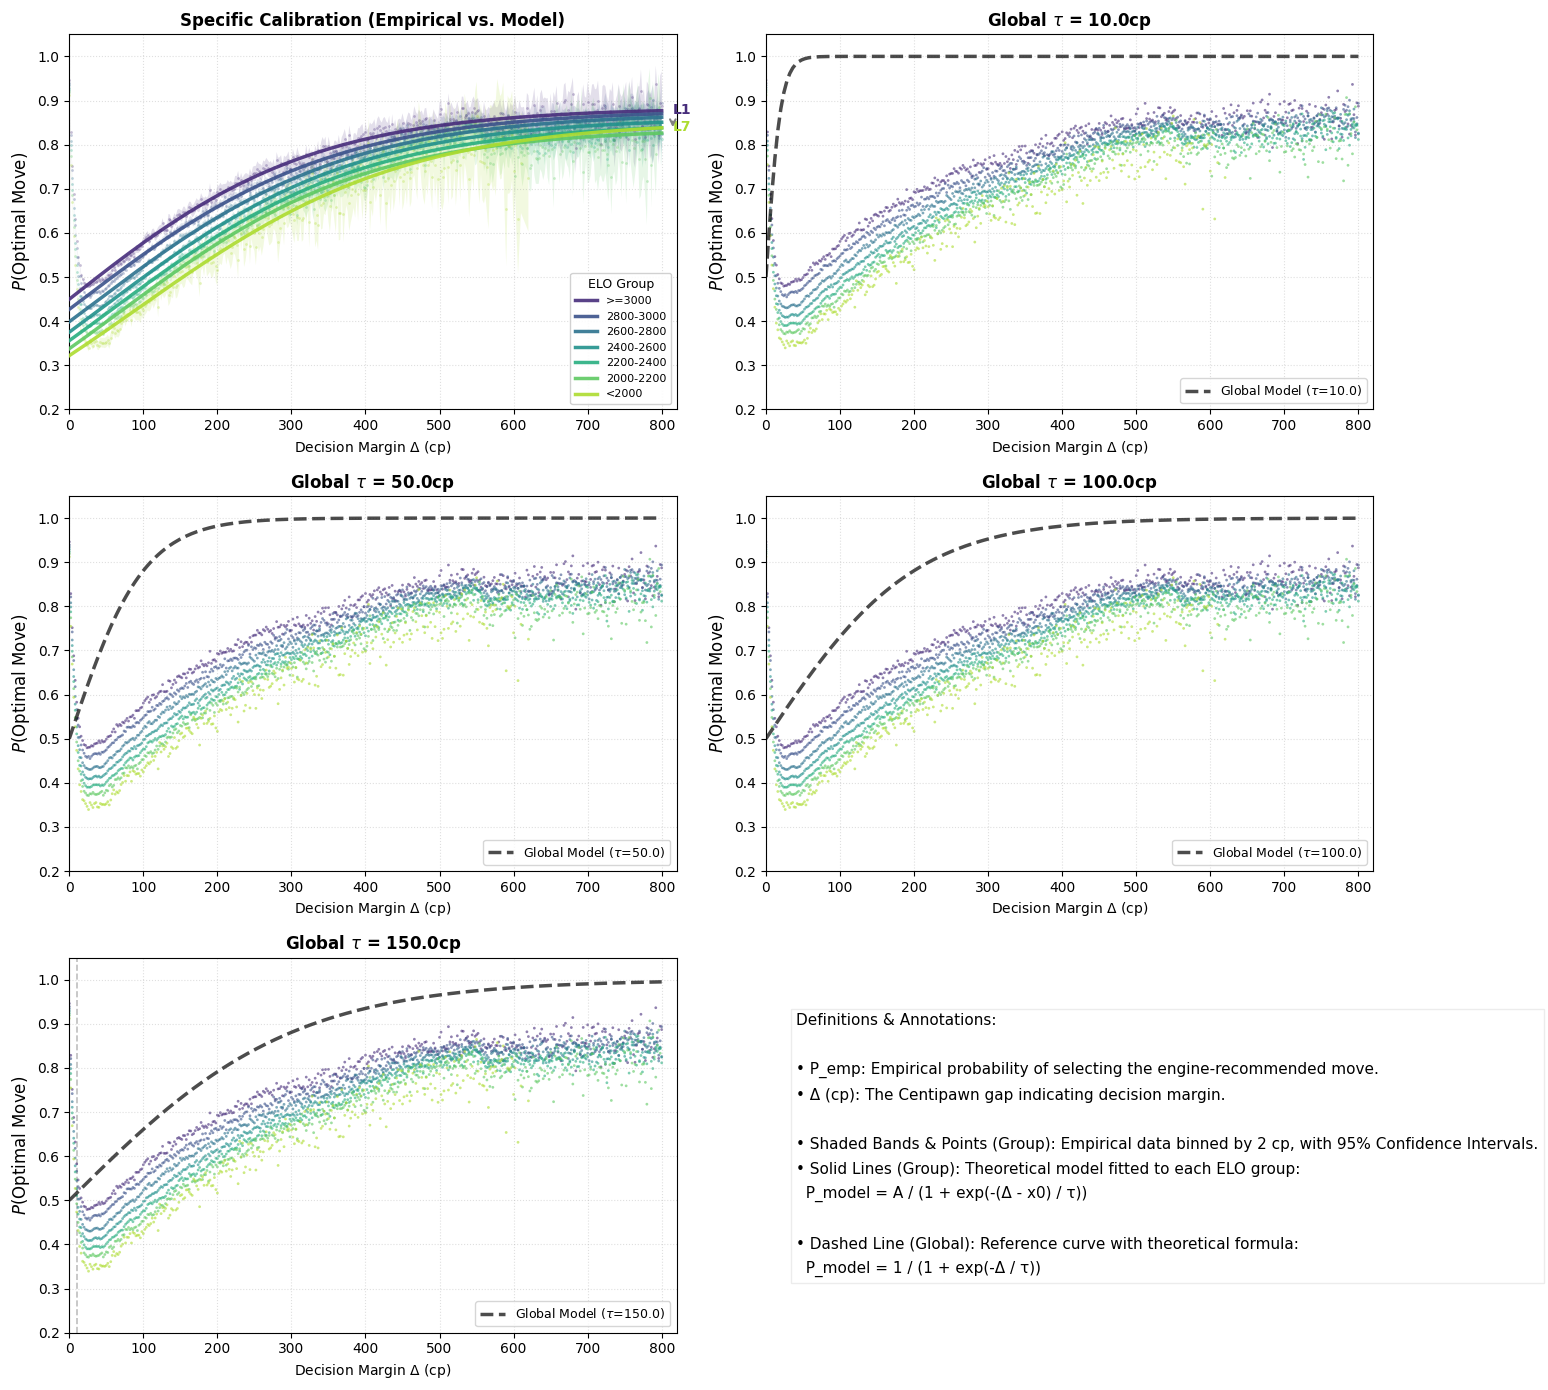

In [3]:
elo_order=['>=3000', '2800-3000', '2600-2800', '2400-2600', '2200-2400', '2000-2200', '<2000'] 
GLOBAL_τ_List = [10.0, 50.0, 100.0, 150.0]

distinct_palette = sns.color_palette("viridis", len(elo_order))

# 基于较大数据集拟合结果
elo_params = {
    '>=3000':      {'A': 0.884, 'τ': 166.9, 'x0': -5.8},
    '2800-3000':   {'A': 0.879, 'τ': 173.1, 'x0': 10.0},
    '2600-2800':   {'A': 0.872, 'τ': 172.7, 'x0': 29.6},
    '2400-2600':   {'A': 0.861, 'τ': 171.6, 'x0': 44.4},
    '2200-2400':   {'A': 0.849, 'τ': 171.5, 'x0': 56.0},
    '2000-2200':   {'A': 0.837, 'τ': 169.2, 'x0': 66.3},
    '<2000':       {'A': 0.855, 'τ': 181.3, 'x0': 91.5}
}

def theoretical_logistic_shifted(x, A, tau, x0):
    x_safe = np.clip(-(x - x0) / tau, -500, 500)
    return A / (1 + np.exp(x_safe))

# --- 核心绘图函数 ---
def plot_delta_performance(data, delta_col, title, ax, tau_val=None, is_group_specific=False, bin_size=2, min_count=50):
    """
    支持单条 Global 参考线或多条 Elo-specific 参考线，并带有 95% CI 误差带
    """
    plot_df = data[(data[delta_col] >= 0) & (data[delta_col] <= 800) & (data['Is_Forced'] == 0)].copy()
    plot_df['Delta_Bin'] = (plot_df[delta_col] // bin_size) * bin_size
    
    # 聚合计算 P_emp 和 Count (用于算误差)
    agg_data = (plot_df.groupby(['ELO_Group', 'Delta_Bin'])['Is_Optimal']
                .agg(P_emp='mean', Count='count')
                .reset_index())
    
    # 切掉样本量过小的噪音尾巴
    agg_data = agg_data[agg_data['Count'] >= min_count]
    
    x_ref = np.linspace(0, 800, 200)
    ax.set_title(title, fontsize=12, fontweight='bold')

    # 把数据绘制循环提出来，所有子图都要画数据底底
    for i, group in enumerate(elo_order):
        group_data = agg_data[agg_data['ELO_Group'] == group].copy()
        if group_data.empty: continue
            
        color = distinct_palette[i]
        
        x_data = group_data['Delta_Bin'].values
        y_data = group_data['P_emp'].values
        n_data = group_data['Count'].values
        
        if is_group_specific:
            # 图 1：画完整的 Error Band 和各自的拟合线
            y_err = 1.96 * np.sqrt(y_data * (1 - y_data) / n_data)
            
            # 误差带
            ax.fill_between(x_data, y_data - y_err, y_data + y_err, 
                            color=color, alpha=0.15, edgecolor='none', zorder=1)
            # 画半透明的散点
            ax.plot(x_data, y_data, 'o', color=color, alpha=0.3, markersize=2, 
                    markeredgecolor='none', zorder=2)
            
            # 拟合实线
            A = elo_params[group]['A']
            tau = elo_params[group]['τ']
            x0 = elo_params[group]['x0']
            y_ref_spec = theoretical_logistic_shifted(x_ref, A, tau, x0)
            ax.plot(x_ref, y_ref_spec, '-', color=color, linewidth=2.5, alpha=0.9, 
                    label=group, zorder=3)
        else:
            # 后面 4 张 Global 图：只画淡淡的经验数据点（不带误差带）
            ax.scatter(x_data, y_data, color=color, s=4, alpha=0.6, edgecolor='none', zorder=1)

    # 追加参考线和标注逻辑
    if is_group_specific:
        # 添加右侧的 L1...L7 标注和箭头逻辑
        label_x = x_ref[-1] + 15
        A_top = elo_params[elo_order[0]]['A']
        tau_top = elo_params[elo_order[0]]['τ']
        x0_top = elo_params[elo_order[0]]['x0']
        y_top = theoretical_logistic_shifted(label_x, A_top, tau_top, x0_top)
        
        A_bottom = elo_params[elo_order[-1]]['A']
        tau_bottom = elo_params[elo_order[-1]]['τ']
        x0_bottom = elo_params[elo_order[-1]]['x0']
        y_bottom = theoretical_logistic_shifted(label_x, A_bottom, tau_bottom, x0_bottom)
        
        ax.text(label_x, y_top, "L1", fontsize=10, ha='left', va='center', color=distinct_palette[0], fontweight='bold')
        ax.text(label_x, y_bottom, "L7", fontsize=10, ha='left', va='center', color=distinct_palette[-1], fontweight='bold')
        ax.annotate('', xy=(label_x, y_bottom), xytext=(label_x, y_top), 
                    arrowprops=dict(arrowstyle='->', color='grey', linewidth=1.5, shrinkA=8, shrinkB=8))
            
    else:
        # 画 Global 的单一黑色虚线
        y_ref_global = 1 / (1 + np.exp(-x_ref / tau_val))
        ax.plot(x_ref, y_ref_global, 'k--', alpha=0.7, linewidth=2.5, 
                label=f'Global Model ($\\tau$={tau_val})', zorder=4)
        ax.legend(loc='lower right', fontsize=9) # 为 Global 图也加上图例说明虚线

    # 通用样式设置
    ax.set_xlabel(r'Decision Margin $\Delta$ (cp)', fontsize=10)
    ax.set_ylabel(r'$P(\text{Optimal Move})$', fontsize=12)
    ax.set_ylim(0.2, 1.05)
    ax.set_xlim(0, 820)
    ax.grid(True, linestyle=':', alpha=0.4)
    if is_group_specific:
        ax.legend(loc='lower right', title="ELO Group", fontsize=8, title_fontsize=9, framealpha=0.9)

# --- 组图装配 ---
fig = plt.figure(figsize=(16, 14))
gs = fig.add_gridspec(3, 2)

# 第一个格子: Group-specific，展示带 Error Band 的拟合图
ax0 = fig.add_subplot(gs[0, 0])
# 注意：这里可以调整 bin_size，推荐 2 到 5
plot_delta_performance(df_moves, 'Δ', 'Specific Calibration (Empirical vs. Model)', ax0, is_group_specific=True, bin_size=2)

# 随后的格子: Global 探测
for idx, tau in enumerate(GLOBAL_τ_List[:4]):
    row, col = (idx + 1) // 2, (idx + 1) % 2
    ax = fig.add_subplot(gs[row, col])
    plot_delta_performance(df_moves, 'Δ', f'Global $\\tau$ = {tau}cp', ax, tau_val=tau)

# 最后一格子：术语与公式说明
ax_legend = fig.add_subplot(gs[2, 1])
ax_legend.axis('off')
ax.axvline(x=10, color='gray', linestyle='--', alpha=0.5, linewidth=1.2, zorder=0)
legend_text = (
    "Definitions & Annotations:\n\n"
    "• P_emp: Empirical probability of selecting the engine-recommended move.\n"
    "• Δ (cp): The Centipawn gap indicating decision margin.\n\n"
    "• Shaded Bands & Points (Group): Empirical data binned by 2 cp, with 95% Confidence Intervals.\n"
    "• Solid Lines (Group): Theoretical model fitted to each ELO group:\n"
    "  P_model = A / (1 + exp(-(Δ - x0) / τ))\n\n"
    "• Dashed Line (Global): Reference curve with theoretical formula:\n"
    "  P_model = 1 / (1 + exp(-Δ / τ))"
)
ax_legend.text(0.05, 0.5, legend_text, fontsize=11, transform=ax_legend.transAxes, 
               va='center', linespacing=1.8, bbox=dict(facecolor='none', edgecolor='gray', alpha=0.15))

plt.tight_layout()
plt.show()

## 开始阶段曲线非常高的原因（猜测）：    
### 由于引擎评分的不稳定性即引擎噪声的存在，在我们定义判一个人类真实决策是否最佳决策的判断方法时，认为只要人类实际走子的引擎得分与引擎给出的最好走子得分的差距在10cp以内，就视为人类的这个决策是最佳决策。    
### 故在横坐标Δ_top5在0-10cp的时候，真实数据点的纵坐标很高。在此种局面下，此时头5个走子都可被认为是最佳走子，人类只要走出其中任何一个都视为做出了最佳决策。  此部分对应开局阶段    


### Picture 1:
分箱： 2cp     
利用二项分布画出其95%的置信区间     
拟合：非线性最小二乘法    
#### poin1：为什么是二项分布？    
任何一个non-force局面，玩家的最终决策均可被抽象为一个binary choice二元分类问题： 走了引擎推荐的最佳棋步（1， success）；走了其他棋步（0， failure）    
在一个特定的Δ分箱内，数据观测到了N步棋，每一步棋都可以看作一次独立的伯努利试验bernoulli trial，假设在这个特定的能力水平和局面清晰度下，选手大脑存在一个客观且未知的“走对率”p，玩家在此分箱种走对的步数为k    
则，在这个N次独立的伯努利试验分箱种，玩家走对的步数k符合二项分布 k~B(N, p)    
“在微观的一局棋中，棋步之间确实存在马尔可夫连带效应。但是，我们在每个 2-cp 的极窄分箱（Bin）中，汇聚了来自数万局不同对局的数十万步棋。在大数定律（Law of Large Numbers）的加持下，局内的自相关性（Autocorrelation）被极大地稀释和平均化了。因此，将该分箱内的样本总量 $N$ 视为独立的伯努利试验是渐近无偏的（Asymptotically unbiased），二项分布假设是完全成立的。”   

#### point2: 95%的置信区间如何求出？    
观测到的经验概率p(^hat)为极大似然估计值MLE, 即p(^hat) = k/N    
由中心极限定理CLT可知，当样本量N足够大时，二项分布可近似为正态分布    
经验概率p(^)的标准误差standard error：    
$$
SE = \sqrt{\frac{\hat{p}(1-\hat{p})}{N}}
$$
95% 置信区间：在进行区间估计时，$z = 1.96$ 是最常用的系数。例如，双侧 95% 置信区间的公式中会使用：

$$
\hat{p} \pm 1.96 \times SE
$$
故经验概率 $\hat{p}$ 的 95% 置信区间（Confidence Interval, CI）的上下界就是：

$$
CI = \hat{p} \pm 1.96 \times \sqrt{\frac{\hat{p}(1-\hat{p})}{N}}
$$   

#### point3：非线性最小二乘法的实现细节：    
目标损失函数为残差平方和SSR，
$$
S(A, \tau, x_0) = \sum_{i=1}^{M} \left( \hat{p}_i - f(\Delta_i; A, \tau, x_0) \right)^2
$$
M为分箱总数量， pihat为真实数据点， f()为模型预测值    
调用了scipy.optimize.curve_fit 进行数值优化。并且由于我们为参数设定了明确的物理边界（例如天花板准确率 $A \in [0, 1]$，参数 $\tau > 0$），底层算法自动选用了 信赖域反射算法（Trust Region Reflective, TRF）。该算法通过不断在当前参数点附近构建泰勒展开的二次近似模型，迭代寻找最优解，直到梯度下降收敛，最终输出了最优参数阵列和协方差矩阵（Covariance Matrix）


### Picture 2-4:    
底图是各个 ELO 分段分箱后的真实散点数据。为了图面清晰，隐去了置信带。图中的黑色粗虚线，是一个强行去掉了天花板参数和平移参数（令 $A=1, x_0=0$），且完全不区分玩家水平的“一刀切”理论模型：

$$
P_{model} = \frac{1}{1 + e^{-\Delta / \tau}}
$$

分别测试了 4 种全局设定的 $\tau$ 值（10, 50, 100, 150）。    
这 4 张图证明，任何试图用单一 Global 模型来概括人类决策复杂度的尝试都会失败。国际象棋中的决策表现，不仅是局面客观难度（$\Delta$）的函数，更是主体认知能力（ELO）的函数

## Picture 2:    
### x-axis: ELO
### y-axis: Δ0

In [4]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5',
       'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Time_Group', 'Move_Time',
       'Game_Length', 'Progress', 'Relative_Stage(temp)', 'P_model', 'S',
       'P_model(Global=10.0cp)', 'S(Global=10.0cp)', 'P_model(Global=50.0cp)',
       'S(Global=50.0cp)', 'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)', 'Cog_Speed'],
      dtype='object')

In [5]:
# 首先要拿到很多ELO和Δ0 x0 A的关系
# --- 1. 准备细分数据 ---
# 假设你的原始数据里有 'ELO' 这一列（原始分数）
bin_size_elo = 40  # 每 50 分为一个刻度点
df_moves['ELO_Bin'] = (df_moves['ELO'] // bin_size_elo) * bin_size_elo

# 获取所有有效的 ELO 箱子并排序
all_elo_bins = sorted(df_moves['ELO_Bin'].unique())
# 过滤掉样本量太少的极端分段（可选）
all_elo_bins = [b for b in all_elo_bins if b >= 1200 and b <= 3000]

all_summary_results = []

# --- 2. 自动化批量拟合循环 ---
print(f"Starting batch fitting for {len(all_elo_bins)} ELO segments...")
# --- 修复版：支持动态分组列 ---
def empirical_curve(df, group_name, delta_min=10, delta_max=800, min_count=100, bin_size=1, group_col='ELO_Group'):
    group_df = df[(df[group_col] == group_name) & (df['Is_Forced'] == 0)]
    
    group_df = group_df[(group_df['Δ'] > delta_min) & (group_df['Δ'] <= delta_max)]
    if group_df.empty: return None
    
    group_df['Δ_bin'] = (group_df['Δ'] // bin_size) * bin_size

    # 计算每个 Δ_bin 的总步数并过滤
    counts = group_df.groupby('Δ_bin')['Is_Optimal'].count()
    valid_deltas = counts[counts >= min_count].index
    group_df = group_df[group_df['Δ_bin'].isin(valid_deltas)]

    if group_df.empty: return None
    
    prob_df = group_df.groupby('Δ_bin')['Is_Optimal'].agg(
        P_Optimal='mean',
        Count='count'
    ).reset_index()
    
    # 重命名列并排序
    prob_df = prob_df.rename(columns={'Δ_bin': 'Δ'})
    prob_df = prob_df.sort_values('Δ').reset_index(drop=True)
    return prob_df

for bin_val in all_elo_bins:
    # 复用你的聚合函数，直接按数值 ELO_Bin 提取数据
    # 注意：这里传入的是数值 bin_val
    prob_df = empirical_curve(df_moves, group_name=bin_val, 
                             delta_min=10, delta_max=800, min_count=200, 
                             group_col='ELO_Bin') # 这里需要微调一下函数，支持自定义列名
    
    if prob_df is None or prob_df.empty:
        continue

    popt, pcov = fit_mse_shifted(prob_df)
    
    if popt is not None:
        A, tau, x0 = popt
        perr = np.sqrt(np.diag(pcov))
        
        all_summary_results.append({
            'ELO_Center': bin_val + bin_size_elo/2, # 取箱子中心点作为横轴坐标
            'A': A,
            'tau': tau,
            'x0': x0,
            'A_err': perr[0],
            'tau_err': perr[1],
            'x0_err': perr[2]
        })

# 转化为结果表
res_df = pd.DataFrame(all_summary_results)
print("Fitting Complete.")

Starting batch fitting for 46 ELO segments...


C:\Users\Administrator\AppData\Local\Temp\ipykernel_27576\4010180223.py:37: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(theoretical_logistic_shifted, x_data, y_data, p0=p0, bounds=bounds)


Fitting Complete.


In [6]:
res_df.shape

(34, 7)

bin_width = 20  # 可以改成 10、20 等
bins = np.arange(df_moves['ELO'].min(), df_moves['ELO'].max() + bin_width, bin_width)
elo_dist = df_moves.groupby(pd.cut(df_moves['ELO'], bins)).size()
pd.set_option('display.max_rows', None)
print(elo_dist)

In [7]:
res_df.to_csv('parameter_est_x0.csv')

In [8]:
res_df = pd.read_csv('parameter_est_x0.csv')
res_df= res_df.iloc[10:]
res_df.head()

,Unnamed: 0,ELO_Center,A,tau,x0,A_err,tau_err,x0_err
10,10,2100.0,1.000000,217.251793,139.290831,0.120111,27.549272,53.725715
11,11,2140.0,0.807236,166.901309,49.422530,0.026301,11.231782,10.314153
12,12,2180.0,0.828347,170.365139,57.236536,0.019880,9.104003,7.761696
13,13,2220.0,0.846347,177.756423,61.323121,0.011535,6.220866,4.549631
14,14,2260.0,0.884422,194.773952,70.821990,0.009950,5.726610,4.155990


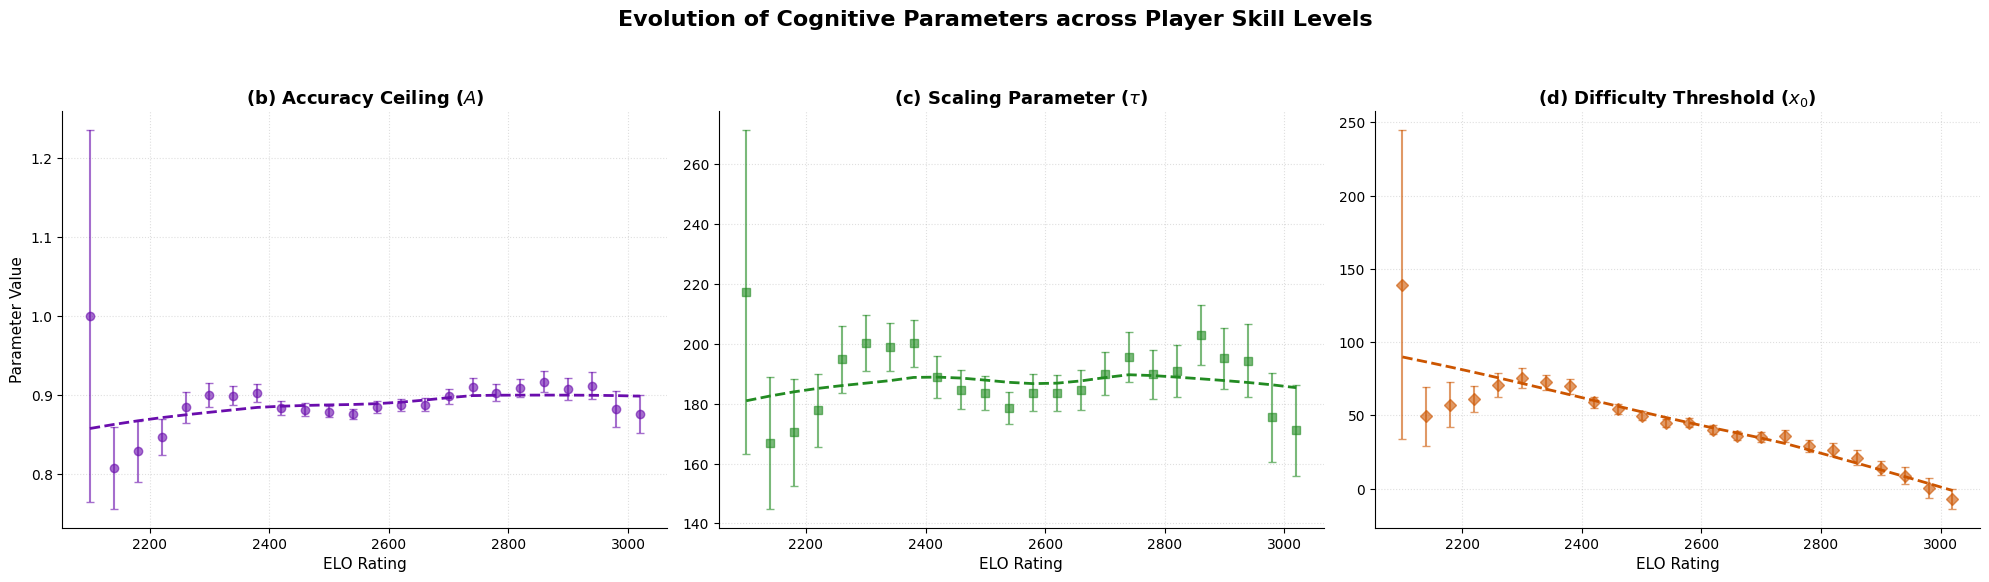

In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5.5))

# (b) Accuracy Ceiling A vs. ELO
ax1.errorbar(res_df['ELO_Center'], res_df['A'], yerr=res_df['A_err']*1.96, 
             fmt='o', color='#6A0DAD', alpha=0.6, capsize=3, label='Estimated A (95% CI)')
sns.regplot(data=res_df, x='ELO_Center', y='A', scatter=False, color='#6A0DAD', 
            ax=ax1, lowess=True, line_kws={'ls':'--', 'lw':2})
ax1.set_title('(b) Accuracy Ceiling ($A$)', fontsize=13, fontweight='bold')
ax1.set_xlabel('ELO Rating', fontsize=11)
ax1.set_ylabel('Parameter Value', fontsize=11)

# (c) Scaling Parameter tau vs. ELO
ax2.errorbar(res_df['ELO_Center'], res_df['tau'], yerr=res_df['tau_err']*1.96, 
             fmt='s', color='#228B22', alpha=0.6, capsize=3, label='Estimated τ (95% CI)')
sns.regplot(data=res_df, x='ELO_Center', y='tau', scatter=False, color='#228B22', 
            ax=ax2, lowess=True, line_kws={'ls':'--', 'lw':2})
ax2.set_title('(c) Scaling Parameter ($\\tau$)', fontsize=13, fontweight='bold')
ax2.set_xlabel('ELO Rating', fontsize=11)
ax2.set_ylabel('', fontsize=11)

# (d) Difficulty Threshold x0 vs. ELO
ax3.errorbar(res_df['ELO_Center'], res_df['x0'], yerr=res_df['x0_err']*1.96, 
             fmt='D', color='#CC5500', alpha=0.6, capsize=3, label='Estimated x0 (95% CI)')
sns.regplot(data=res_df, x='ELO_Center', y='x0', scatter=False, color='#CC5500', 
            ax=ax3, lowess=True, line_kws={'ls':'--', 'lw':2})
ax3.set_title('(d) Difficulty Threshold ($x_0$)', fontsize=13, fontweight='bold')
ax3.set_xlabel('ELO Rating', fontsize=11)
ax3.set_ylabel('', fontsize=11)

# 通用修饰
for ax in [ax1, ax2, ax3]:
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Evolution of Cognitive Parameters across Player Skill Levels', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

看一下是不是纵轴是横轴x的sinx/x函数

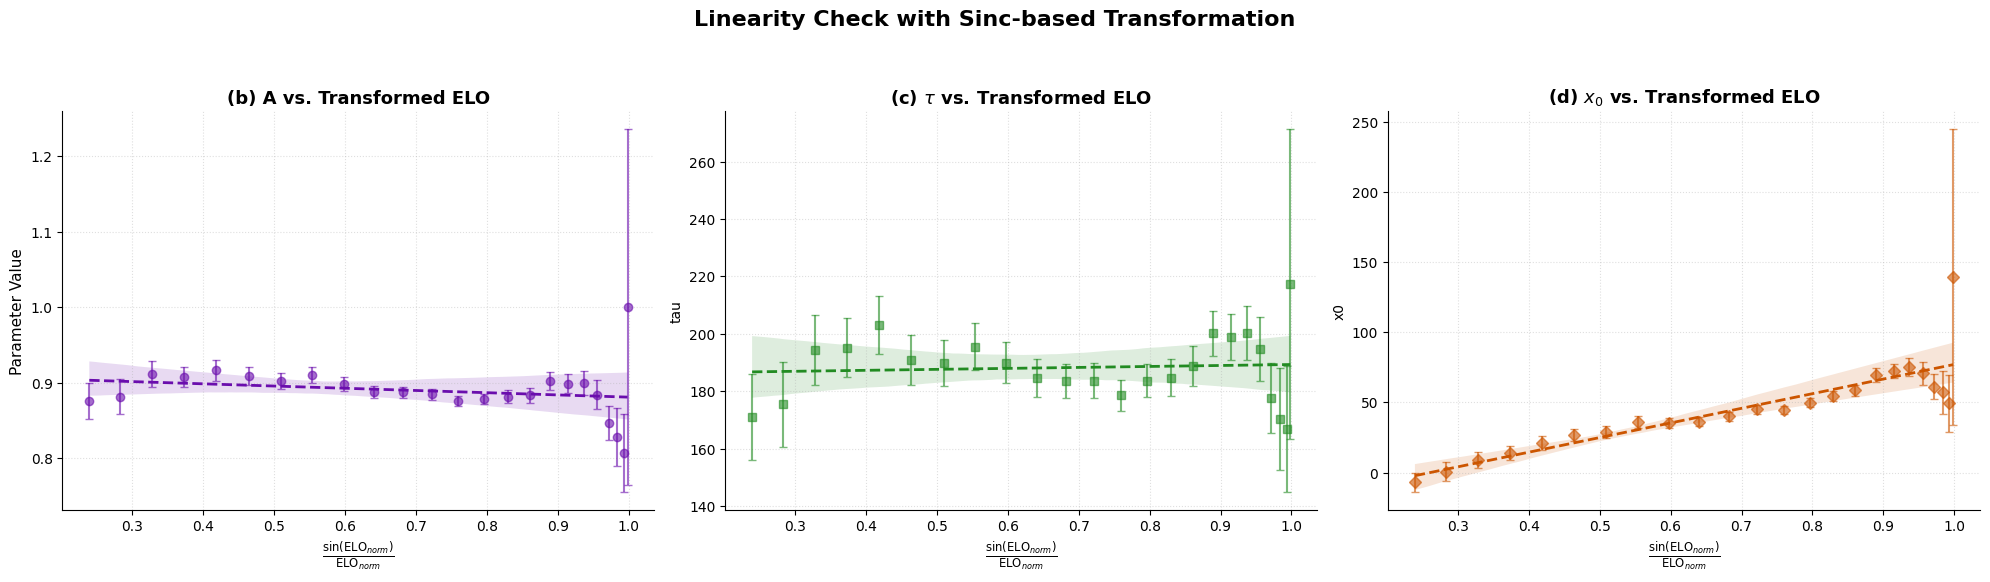

In [10]:
# --- 1. 数据预处理：归一化 ELO 到 [0.1, pi-0.1] ---
# 必须映射到这个区间，否则 sin 会因为数值太大或接近 0/pi 而报错
elo_min, elo_max = res_df['ELO_Center'].min(), res_df['ELO_Center'].max()
# 映射函数：将 ELO 线性映射到 0.1 到 2.5 弧度之间（避开 0 和 pi 的奇异点）
res_df['x_norm'] = 0.1 + (res_df['ELO_Center'] - elo_min) / (elo_max - elo_min) * 2.4

# --- 2. 选择变换方式 (在这里切换) ---
# 方式 A: sin(x)/x
res_df['x_trans'] = np.sin(res_df['x_norm']) / res_df['x_norm']
x_label = r'$\frac{\sin(\text{ELO}_{norm})}{\text{ELO}_{norm}}$'

# 方式 B: x/sin(x) (如果想试这个，取消下面这行注释)
# res_df['x_trans'] = res_df['x_norm'] / np.sin(res_df['x_norm'])
# x_label = r'$\frac{\text{ELO}_{norm}}{\sin(\text{ELO}_{norm})}$'

# --- 3. 绘图 ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5.5))

# (b) Accuracy Ceiling A
ax1.errorbar(res_df['x_trans'], res_df['A'], yerr=res_df['A_err']*1.96, 
             fmt='o', color='#6A0DAD', alpha=0.6, capsize=3)
sns.regplot(data=res_df, x='x_trans', y='A', scatter=False, color='#6A0DAD', 
            ax=ax1, ci=95, line_kws={'ls':'--', 'lw':2}) # 这里改成了线性回归
ax1.set_title('(b) A vs. Transformed ELO', fontsize=13, fontweight='bold')
ax1.set_xlabel(x_label, fontsize=12)
ax1.set_ylabel('Parameter Value', fontsize=11)

# (c) Scaling Parameter tau
ax2.errorbar(res_df['x_trans'], res_df['tau'], yerr=res_df['tau_err']*1.96, 
             fmt='s', color='#228B22', alpha=0.6, capsize=3)
sns.regplot(data=res_df, x='x_trans', y='tau', scatter=False, color='#228B22', 
            ax=ax2, ci=95, line_kws={'ls':'--', 'lw':2})
ax2.set_title('(c) $\\tau$ vs. Transformed ELO', fontsize=13, fontweight='bold')
ax2.set_xlabel(x_label, fontsize=12)

# (d) Difficulty Threshold x0
ax3.errorbar(res_df['x_trans'], res_df['x0'], yerr=res_df['x0_err']*1.96, 
             fmt='D', color='#CC5500', alpha=0.6, capsize=3)
sns.regplot(data=res_df, x='x_trans', y='x0', scatter=False, color='#CC5500', 
            ax=ax3, ci=95, line_kws={'ls':'--', 'lw':2})
ax3.set_title('(d) $x_0$ vs. Transformed ELO', fontsize=13, fontweight='bold')
ax3.set_xlabel(x_label, fontsize=12)

for ax in [ax1, ax2, ax3]:
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Linearity Check with Sinc-based Transformation', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [11]:
def print_linearity_report(df, x_col, target_cols):
    print(f"\n" + "="*40)
    print(f"线性相关性分析报告 (自变量: {x_col})")
    print("="*40)
    print(f"{'参数':<10} | {'Pearson R':<12} | {'R^2':<10} | {'p-value':<10}")
    print("-" * 40)
    
    for col in target_cols:
        # 剔除无效数据
        mask = ~df[col].isna() & ~df[x_col].isna()
        x = df.loc[mask, x_col]
        y = df.loc[mask, col]
        
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        print(f"{col:<10} | {r_value:<12.4f} | {r_value**2:<10.4f} | {p_value:<10.4f}")

# 在绘图之前或之后调用这个函数
target_cols = ['A', 'tau', 'x0']
print_linearity_report(res_df, 'x_trans', target_cols)
print_linearity_report(res_df, 'ELO_Center', target_cols)



线性相关性分析报告 (自变量: x_trans)
参数         | Pearson R    | R^2        | p-value   
----------------------------------------
A          | -0.2087      | 0.0435     | 0.3278    
tau        | 0.0714       | 0.0051     | 0.7402    
x0         | 0.8600       | 0.7396     | 0.0000    

线性相关性分析报告 (自变量: ELO_Center)
参数         | Pearson R    | R^2        | p-value   
----------------------------------------
A          | 0.1951       | 0.0381     | 0.3608    
tau        | -0.0688      | 0.0047     | 0.7494    
x0         | -0.8717      | 0.7598     | 0.0000    


# version 2: P_model only related to A, τ

# 对比一下到底拟合几个参数效果好一点

### 1. P(Δ) = A / (1 + np.exp(-x / tau))
### 2. P(Δ) = A / (1 + np.exp(-(x - x0) / tau))

In [12]:
prob_df.head()

,Δ,P_Optimal,Count
0,11.0,0.566571,21263
1,12.0,0.553285,20212
2,13.0,0.536585,18819
3,14.0,0.530632,17645
4,15.0,0.522951,16579



>>> 正在处理 ELO 组: >=3000


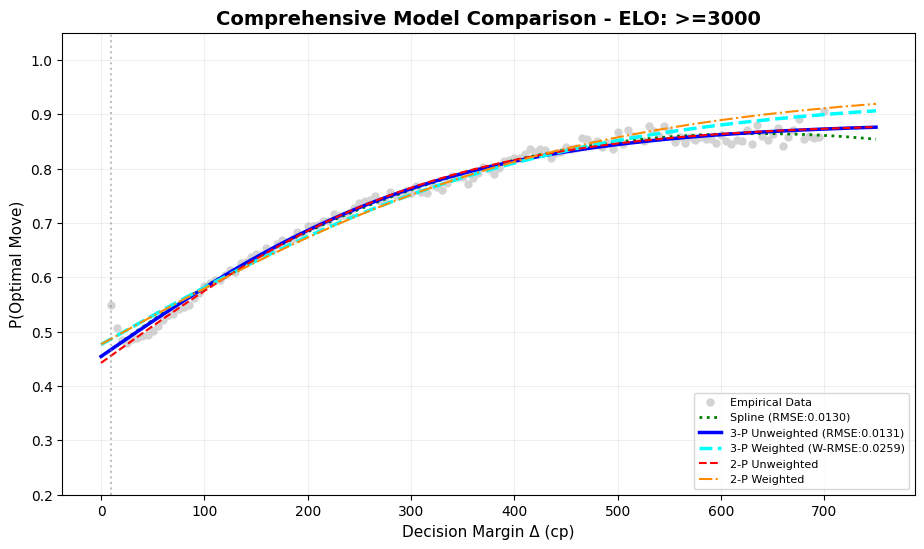


>>> 正在处理 ELO 组: 2800-3000


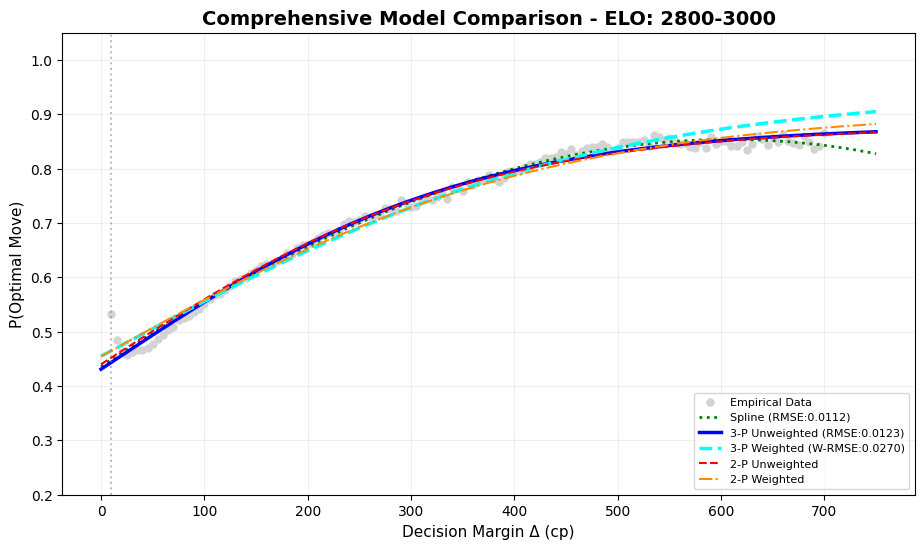


>>> 正在处理 ELO 组: 2600-2800


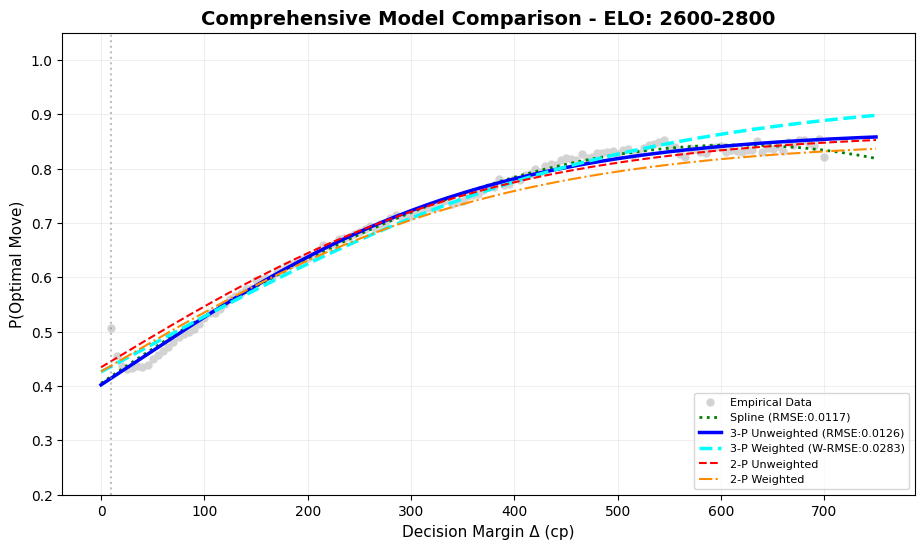


>>> 正在处理 ELO 组: 2400-2600


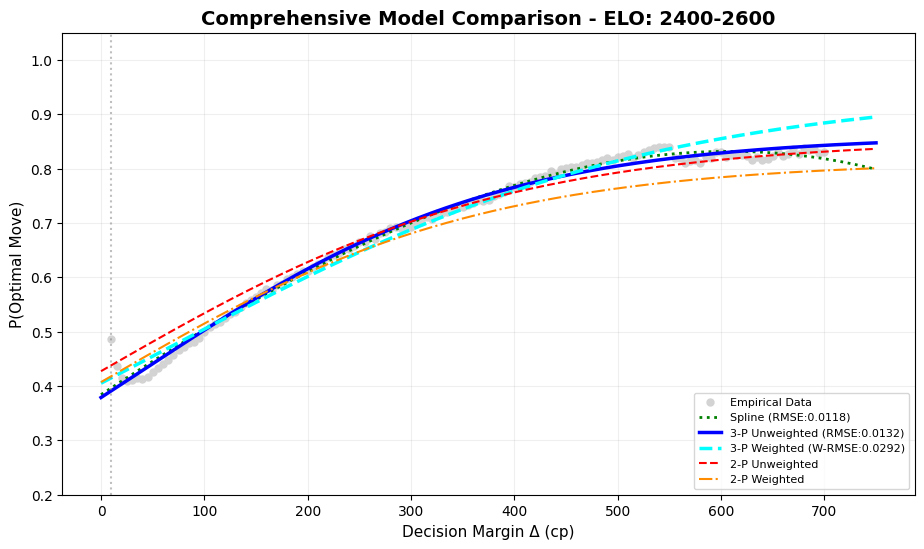


>>> 正在处理 ELO 组: 2200-2400


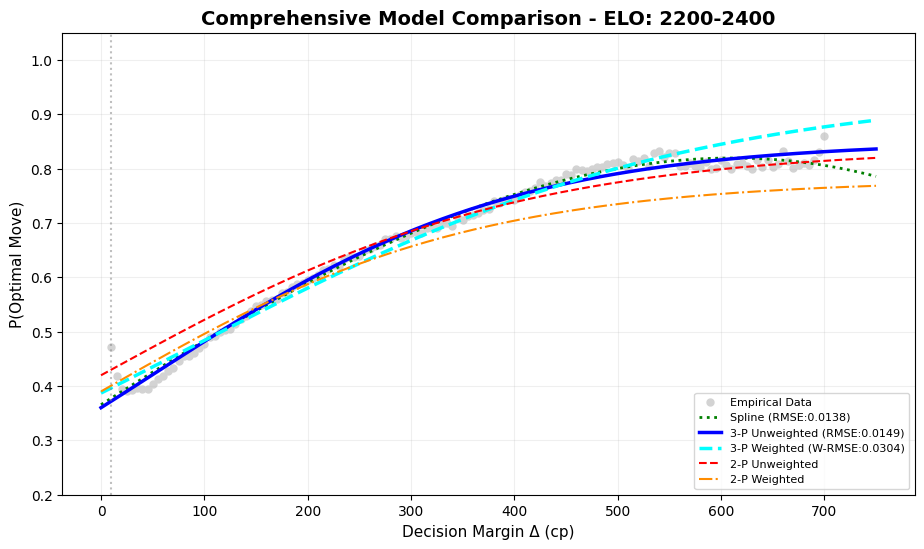


>>> 正在处理 ELO 组: 2000-2200


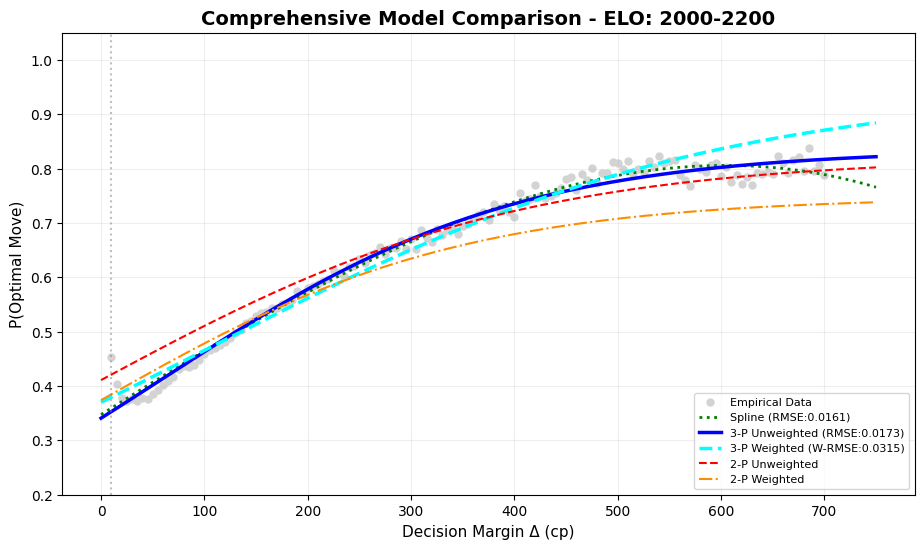


>>> 正在处理 ELO 组: <2000


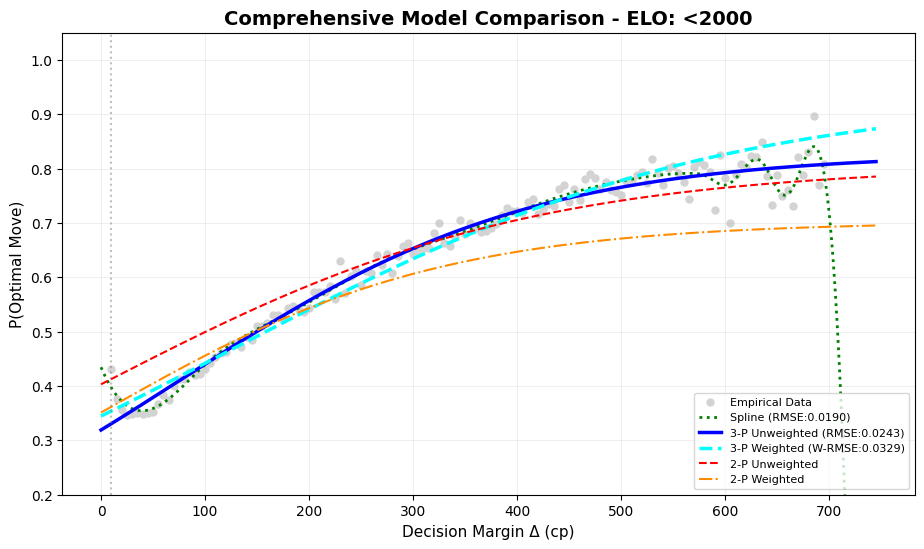


################################################################################
FINAL GLOBAL SUMMARY TABLE (With Weighted RMSE)
################################################################################
      ELO         Method         A         tau          x0    RMSE  W_RMSE
   >=3000         Spline         -           -           - 0.01297 0.02933
   >=3000 3-P Unweighted  0.886041  169.094614    -8.70905 0.01309 0.02919
   >=3000   3-P Weighted  0.934115   217.57848   -8.545552 0.01826 0.02595
   >=3000 2-P Unweighted  0.885058  162.168692         N/A 0.01362 0.03325
   >=3000   2-P Weighted  0.953424  228.213207         N/A 0.02165 0.02604
2800-3000         Spline         -           -           - 0.01117 0.02952
2800-3000 3-P Unweighted  0.880027  174.434267    7.144064 0.01235 0.03090
2800-3000   3-P Weighted  0.943129  232.030911   16.433873 0.01945 0.02702
2800-3000 2-P Unweighted  0.880035  179.466646         N/A 0.01274 0.02894
2800-3000   2-P Weighted  0.908888  214

In [20]:
# --- 1. 模型函数与辅助函数定义 ---
def model_2param(x, A, tau):
    return A / (1 + np.exp(-x / tau))

def model_3param(x, A, tau, x0):
    x_safe = np.clip(-(x - x0) / tau, -500, 500)
    return A / (1 + np.exp(x_safe))

def get_weighted_rmse(y_obs, y_pred, sigmas):
    """计算加权均方根误差 (W-RMSE)"""
    weights = 1.0 / (sigmas**2)
    weighted_sq_err = weights * (y_obs - y_pred)**2
    return np.sqrt(np.sum(weighted_sq_err) / np.sum(weights))

# --- 2. 配置 ---
group_order = ['>=3000', '2800-3000', '2600-2800', '2400-2600', '2200-2400', '2000-2200', '<2000']
group_configs = {
    '>=3000':   {'delta_max': 700, 'min_count': 50},
    '2800-3000':{'delta_max': 700, 'min_count': 50},
    '2600-2800':{'delta_max': 700, 'min_count': 80},
    '2400-2600':{'delta_max': 700, 'min_count': 100},
    '2200-2400':{'delta_max': 700, 'min_count': 100},
    '2000-2200':{'delta_max': 700, 'min_count': 50},
    '<2000':    {'delta_max': 700, 'min_count': 50}
}

all_records = []

# --- 3. 核心循环 ---
for g in group_order:
    print(f"\n>>> 正在处理 ELO 组: {g}")
    cfg = group_configs.get(g)
    
    # 获取数据
    prob_df = empirical_curve(df_moves[df_moves['Is_Forced'] == 0], 
                              group_name=g, delta_min=10, delta_max=cfg['delta_max'], 
                              min_count=cfg['min_count'], bin_size=5)
    if prob_df is None or prob_df.empty: continue

    x_data, y_data, n_data = prob_df['Δ'].values, prob_df['P_Optimal'].values, prob_df['Count'].values
    y_safe = np.clip(y_data, 1e-4, 1 - 1e-4)
    sigmas = np.sqrt(y_safe * (1 - y_safe) / n_data)

    plt.figure(figsize=(11, 6))
    plt.scatter(x_data, y_data, color='lightgray', s=25, label='Empirical Data', zorder=1)
    x_smooth = np.linspace(0, x_data.max() + 50, 400)
    
    # --- 各种方法拟合与评价 ---
    
    # 1. Spline (基准)
    try:
        spline = UnivariateSpline(x_data, y_data, s=0.05)
        y_spline = spline(x_data)
        rmse_s = np.sqrt(mean_squared_error(y_data, y_spline))
        w_rmse_s = get_weighted_rmse(y_data, y_spline, sigmas)
        plt.plot(x_smooth, spline(x_smooth), ':', color='green', lw=2, label=f'Spline (RMSE:{rmse_s:.4f})')
        all_records.append({'ELO': g, 'Method': 'Spline', 'A': '-', 'tau': '-', 'x0': '-', 'RMSE': rmse_s, 'W_RMSE': w_rmse_s})
    except: pass

    # 2. 3-P Logistic (Unweighted)
    try:
        popt3u, _ = curve_fit(model_3param, x_data, y_data, p0=[0.9, 150, 50], bounds=([0, 0, -500], [1, 1000, 500]))
        y_3pu = model_3param(x_data, *popt3u)
        rmse3u = np.sqrt(mean_squared_error(y_data, y_3pu))
        w_rmse3u = get_weighted_rmse(y_data, y_3pu, sigmas)
        plt.plot(x_smooth, model_3param(x_smooth, *popt3u), '-', color='blue', lw=2.5, label=f'3-P Unweighted (RMSE:{rmse3u:.4f})')
        all_records.append({'ELO': g, 'Method': '3-P Unweighted', 'A': popt3u[0], 'tau': popt3u[1], 'x0': popt3u[2], 'RMSE': rmse3u, 'W_RMSE': w_rmse3u})
    except: pass

    # 3. 3-P Logistic (Weighted)
    try:
        popt3w, _ = curve_fit(model_3param, x_data, y_data, p0=[0.9, 150, 50], sigma=sigmas, absolute_sigma=True, bounds=([0, 0, -500], [1, 1000, 500]))
        y_3pw = model_3param(x_data, *popt3w)
        rmse3w = np.sqrt(mean_squared_error(y_data, y_3pw))
        w_rmse3w = get_weighted_rmse(y_data, y_3pw, sigmas)
        plt.plot(x_smooth, model_3param(x_smooth, *popt3w), '--', color='cyan', lw=2.5, label=f'3-P Weighted (W-RMSE:{w_rmse3w:.4f})')
        all_records.append({'ELO': g, 'Method': '3-P Weighted', 'A': popt3w[0], 'tau': popt3w[1], 'x0': popt3w[2], 'RMSE': rmse3w, 'W_RMSE': w_rmse3w})
    except: pass

    # 4. 2-P Logistic (Unweighted)
    try:
        popt2u, _ = curve_fit(model_2param, x_data, y_data, p0=[0.9, 150], bounds=([0.0, 1.0], [1.0, 2000.0]))
        y_2pu = model_2param(x_data, *popt2u)
        rmse2u = np.sqrt(mean_squared_error(y_data, y_2pu))
        w_rmse2u = get_weighted_rmse(y_data, y_2pu, sigmas)
        plt.plot(x_smooth, model_2param(x_smooth, *popt2u), '--', color='red', lw=1.5, label=f'2-P Unweighted')
        all_records.append({'ELO': g, 'Method': '2-P Unweighted', 'A': popt2u[0], 'tau': popt2u[1], 'x0': 'N/A', 'RMSE': rmse2u, 'W_RMSE': w_rmse2u})
    except: pass

    # 5. 2-P Logistic (Weighted)
    try:
        popt2w, _ = curve_fit(model_2param, x_data, y_data, p0=[0.9, 150], sigma=sigmas, absolute_sigma=True, bounds=([0.0, 1.0], [1.0, 2000.0]))
        y_2pw = model_2param(x_data, *popt2w)
        rmse2w = np.sqrt(mean_squared_error(y_data, y_2pw))
        w_rmse2w = get_weighted_rmse(y_data, y_2pw, sigmas)
        plt.plot(x_smooth, model_2param(x_smooth, *popt2w), '-.', color='darkorange', lw=1.5, label='2-P Weighted')
        all_records.append({'ELO': g, 'Method': '2-P Weighted', 'A': popt2w[0], 'tau': popt2w[1], 'x0': 'N/A', 'RMSE': rmse2w, 'W_RMSE': w_rmse2w})
    except: pass

    # 装饰
    plt.axvline(x=10, color='gray', linestyle=':', alpha=0.5)
    plt.title(f'Comprehensive Model Comparison - ELO: {g}', fontsize=14, fontweight='bold')
    plt.xlabel('Decision Margin Δ (cp)', fontsize=11)
    plt.ylabel('P(Optimal Move)', fontsize=11)
    plt.legend(loc='lower right', fontsize=8, framealpha=0.8)
    plt.grid(alpha=0.2); plt.ylim(0.2, 1.05); plt.show()

# --- 4. 汇总大表 ---
final_df = pd.DataFrame(all_records)
final_df = final_df[['ELO', 'Method', 'A', 'tau', 'x0', 'RMSE', 'W_RMSE']]
print("\n" + "#"*80 + "\nFINAL GLOBAL SUMMARY TABLE (With Weighted RMSE)\n" + "#"*80)
print(final_df.to_string(index=False, formatters={'RMSE': '{:.5f}'.format, 'W_RMSE': '{:.5f}'.format}))


===== ELO group: >=3000 =====
使用参数 -> delta_max: 700, min_count: 50
最优天花板 A   = 0.883
最优阈值 τ     = 162.2


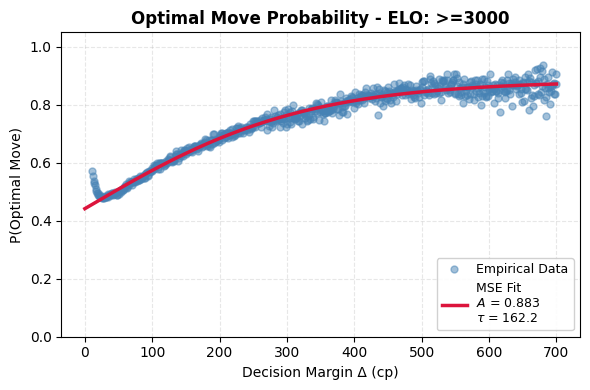


===== ELO group: 2800-3000 =====
使用参数 -> delta_max: 700, min_count: 50
最优天花板 A   = 0.879
最优阈值 τ     = 180.3


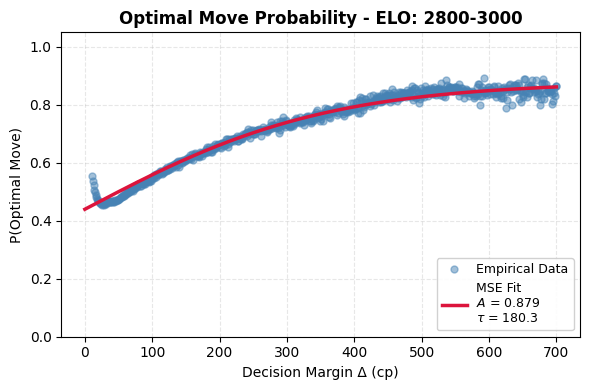


===== ELO group: 2600-2800 =====
使用参数 -> delta_max: 700, min_count: 80
最优天花板 A   = 0.870
最优阈值 τ     = 191.6


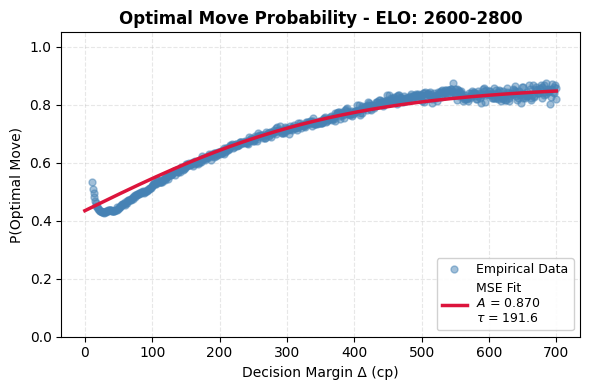


===== ELO group: 2400-2600 =====
使用参数 -> delta_max: 700, min_count: 100
最优天花板 A   = 0.854
最优阈值 τ     = 197.5


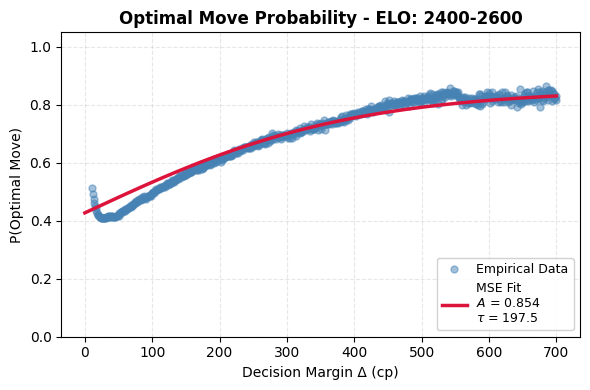


===== ELO group: 2200-2400 =====
使用参数 -> delta_max: 700, min_count: 100
最优天花板 A   = 0.838
最优阈值 τ     = 201.8


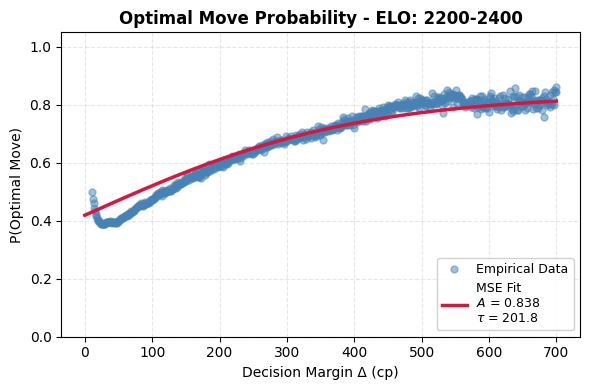


===== ELO group: 2000-2200 =====
使用参数 -> delta_max: 700, min_count: 50
最优天花板 A   = 0.822
最优阈值 τ     = 203.9


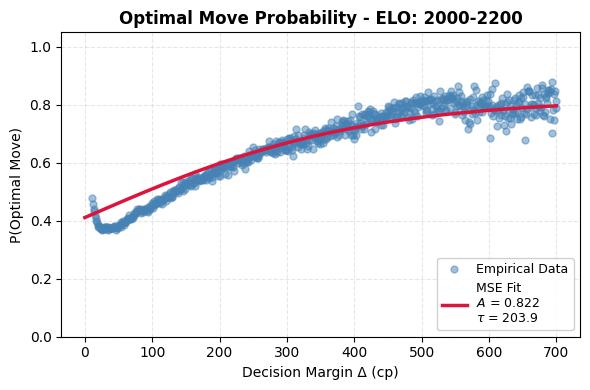


===== ELO group: <2000 =====
使用参数 -> delta_max: 700, min_count: 50
最优天花板 A   = 0.774
最优阈值 τ     = 184.5


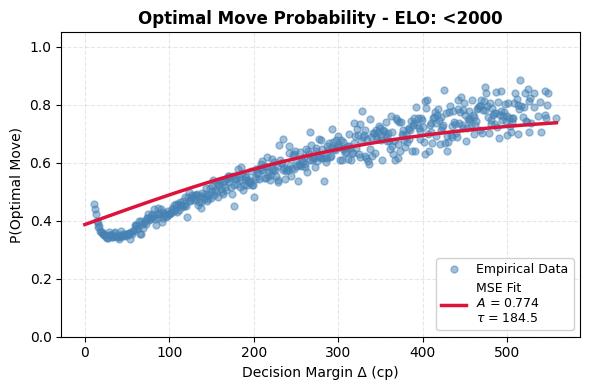

In [17]:
# 定制每个组的参数
group_configs = {
    '>=3000':   {'delta_max': 700, 'min_count': 50},
    '2800-3000':{'delta_max': 700, 'min_count': 50},
    '2600-2800':{'delta_max': 700, 'min_count': 80},
    '2400-2600':{'delta_max': 700, 'min_count': 100},
    '2200-2400':{'delta_max': 700, 'min_count': 100},
    '2000-2200':{'delta_max': 700, 'min_count': 50},
    '<2000':    {'delta_max': 700, 'min_count': 50}
}
def theoretical_logistic(delta, A, tau):
    exponent = np.clip(-delta/tau, -700, 700)
    return A/(1+ np.exp(exponent))

def fit_mse(prob_df):
    if prob_df is None or prob_df.empty:
        return None, None
    x_data = prob_df['Δ'].values
    y_data = prob_df['P_Optimal'].values
    initial_guess = [y_data.max(), 100.0]
    bounds = ([0.0, 1.0], [1.0, 2000.0])
    try:
        popt, _ = curve_fit(
            theoretical_logistic, 
            x_data, y_data, 
            p0=initial_guess, 
            bounds=bounds
        )
        return popt[0], popt[1]  # 返回最优的 A 和 tau
    except Exception as e:
        print(f"拟合失败: {e}")
        return None, None
    
all_prob_curves = {}
results = {}
group_order = ['>=3000', '2800-3000', '2600-2800','2400-2600', '2200-2400', '2000-2200', '<2000']

for g in group_order:
    print(f'\n===== ELO group: {g} =====')

    # 从你的配置字典里读取专属参数
    cfg = group_configs.get(g, {'delta_max': 1000, 'min_count': 100})
    d_max = cfg['delta_max']
    m_cnt = cfg['min_count']
    
    print(f'使用参数 -> delta_max: {d_max}, min_count: {m_cnt}')

    # 获取聚合后的经验散点数据
    prob_df = empirical_curve(df_moves[df_moves['Is_Forced'] == 0], group_name=g, delta_min=10, delta_max=d_max, min_count=m_cnt)

    if prob_df is None:
        print('No valid data.')
        continue

    # 执行严谨的 MSE 拟合
    A, tau = fit_mse(prob_df)
    
    if A is None:
        continue

    print(f'最优天花板 A   = {A:.3f}')
    print(f'最优阈值 τ     = {tau:.1f}')

    all_prob_curves[g] = prob_df
    results[g] = {'A': A, 'tau': tau}
    
    # ==========================================
    # 画图：散点和曲线异色显示
    # ==========================================
    plt.figure(figsize=(6, 4))
    
    x_data = prob_df['Δ'].values
    y_data = prob_df['P_Optimal'].values
    
    # 1. 散点：使用半透明的钢蓝色 (steelblue)
    plt.plot(x_data, y_data, 'o', color='steelblue', alpha=0.5, markersize=5, label='Empirical Data')
    
    # 2. 曲线：使用鲜艳的深红色 (crimson)
    x_smooth = np.linspace(0, x_data.max(), 200) 
    y_smooth = theoretical_logistic(x_smooth, A, tau)
    
    fit_label = f'MSE Fit\n$A$ = {A:.3f}\n$\\tau$ = {tau:.1f}'
    plt.plot(x_smooth, y_smooth, '-', color='crimson', lw=2.5, label=fit_label)

    # 排版美化
    plt.title(f'Optimal Move Probability - ELO: {g}', fontsize=12, fontweight='bold')
    plt.xlabel('Decision Margin Δ (cp)', fontsize=10)
    plt.ylabel('P(Optimal Move)', fontsize=10)
    plt.ylim(0, 1.05)
    
    plt.legend(loc='lower right', fontsize=9, framealpha=0.9)
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()